<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Classification%20Matrixes%20on%20Mariage%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
data = pd.read_csv("melbourne_marriages_100.csv")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [48]:
data
X = data.drop('Is_First_Marriage',axis=1)
y = data['Is_First_Marriage']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=X.columns)
X_train
logis = LogisticRegression(class_weight='balanced')
train = logis.fit(X_train,y_train)
pred = logis.predict(X_test)
pd.DataFrame(pred)
accuracy_score(y_test,pred)*100

confusion_matrix(y_test, pred)


precision_score(y_test,pred)
recall_score(y_test,pred)
f1_score(y_test,pred)
roc_auc_score(y_test,pred)


np.float64(0.7916666666666667)

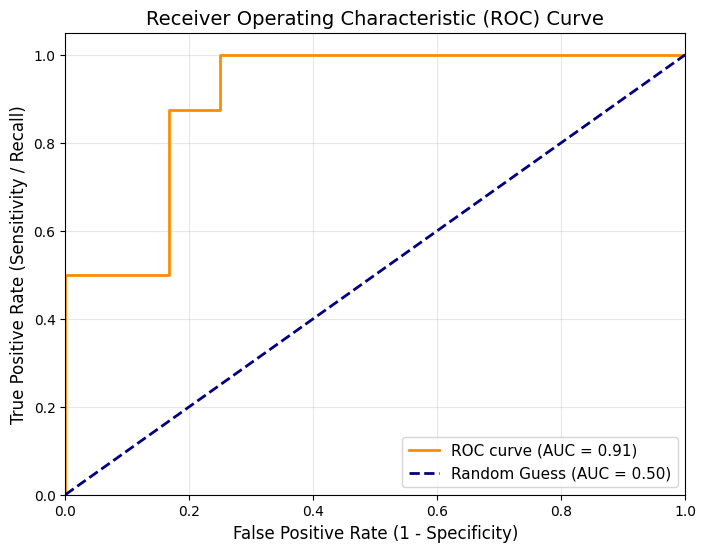

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the predicted probabilities for the positive class (Is_First_Marriage = 1)
# Note: Use predict_proba on your test features (X_test), not hard predictions
y_prob = logis.predict_proba(X_test)[:, 1]

# 2. Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 3. Calculate the AUC score for the plot title/legend
auc_score = roc_auc_score(y_test, y_prob)

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')

# Plot the baseline (random guessing line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Show the plot
plt.show()